# DE300 Project: Early Warning Water Quality Risk Detection System and Forecasting

## Project Roadmap:
1. **Goal**: Building a system that can *detect early warning signals of water quality degradation* by forecasting chemical levels 3 months into the future.
    - Identifies locations where trends indicate potential future risk.
    - **Output**: A risk score per location predicting future degradation.
    
2. **Location Selection and Feasibility Analysis**: Test multiple locations (large cities, cities with known degradation over time, cities with known poor water quality) --> determine feasibility for model
    - Evaluate based on time span of data, sampling frequency, data density/sparsity, presence of long-term trends, and seasonal patterns
    - Identify 10 locations that provide sufficient data to support our forecasting model

3. **Data Ingestion Pipeline**: From the *Water Quality Portal (WQP) webservice API*, collect relevant data.
    - **Pipeline**: 
        - query WQP API
        - retrieve measurements for selected locations
        - store raw data (S3 or locally)

4. **Data Cleaning and Standardization**
    - complete unit normalization for unique measurement types
    - aggregate measurements into monthly averages
    - identify gaps in handling
        - forward fill short gaps

5. **Exploratory Data Analysis (EDA)**L understand how water quality evolves over time
    - **Key Analyses**: time series visualization, chemical levels per location over time, trend detection


6. **Feature Engineering**: convert time series into model-ready features
    - **Features**: 
        - previous chemical levels (*lag features*)
        - rolling averages (3 months)
        - month of year (seasonality)

7. **Forecasting Model (Trend Prediction)**
    - train a global model across multiple locations
    - all locations contribute training examples
    - each *training example*:
        - input last X months of data, output predicted measurement at t+3 months
    - **Lookback Window**: 12-24 months of historical data
    - **Prediction Target**: chemical level in 3 months
    - **Model**: Random Forest
        - Based on data analysis, Random Forest was chosen due to the size of the final modeling dataset with tabular features.
        - Very robust for noisy environmental data, handles nonlinear relationships, noisy predictors, and missin structure
        - simpler models preferred for early prototypes

8. **Early Warning Risk Detection**: Convert predictions into *risk signals*
    - Determine *risk thresholds* based on regulations
    - Calculate risk score and categorize into low, medium, and high


9. **Pipeline Automation** (if time allows): Use *Airflow DAG* to orchestrate the workflow.
    - Ensure the system can *continously update forecasts*

10. **Output Storage**: Store predictions and risk results (locally, S3, NoSQL database)

11. **Final Deliverables**:
    - Forecasts of water quality 3 months ahead
    - Interpretable risk scores per location


### Building the Global Dataset
Now we will begin building the dataset based on desired data from our 10 locations that we've determined sufficient.

The data will be stored locally for now, intending to move this to AWS S3 in the future.

In [ ]:
import os

# storing data in data/raw folder
os.makedirs("data/raw", exist_ok=True)

### Retrieving Locally Stored Data
Each location has it's own notebook where the WQP API was called for the locations *bounding box*. The resulting dataframe created was stored in `data/raw` with corresponding names of the locations.

In [214]:
import pandas as pd

files = {
    "riverview": "data/raw/riverview.csv",
    "houston_buffalo_bayou": "data/raw/houston.csv",
    "des_moines": "data/raw/des_moines.csv",
    "sacramento": "data/raw/sacramento.csv",
    "baton_rouge": "data/raw/baton_rouge.csv",
    "kansas_city": "data/raw/kansas_city.csv",
    "memphis": "data/raw/memphis.csv",
    "toledo": "data/raw/toledo.csv",
    "st_louis": "data/raw/st_louis.csv",
    "columbus": "data/raw/columbus.csv",
}

dfs = []

for location, path in files.items():
    df = pd.read_csv(path)
    df["location"] = location
    dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

print(raw_df.shape)
raw_df.head()

C:\Users\kcui2\AppData\Local\Temp\ipykernel_28888\3305303501.py:19: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
C:\Users\kcui2\AppData\Local\Temp\ipykernel_28888\3305303501.py:19: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
C:\Users\kcui2\AppData\Local\Temp\ipykernel_28888\3305303501.py:19: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
C:\Users\kcui2\AppData\Local\Temp\ipykernel_28888\3305303501.py:19: DtypeWarning: Columns (8,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
C:\Users\kcui2\AppData\Local\Temp\ipykernel_28888\3305303501.py:19: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


(537157, 19)


C:\Users\kcui2\AppData\Local\Temp\ipykernel_28888\3305303501.py:19: DtypeWarning: Columns (2,3,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,ActivityStartDate,ActivityStartTime/Time,ActivityEndDate,ActivityEndTime/Time,MonitoringLocationIdentifier,ActivityDepthHeightMeasure/MeasureValue,ActivityMediaName,CharacteristicName,ResultMeasureValue,ResultMeasure/MeasureUnitCode,ResultStatusIdentifier,MeasureQualifierCode,DetectionQuantitationLimitMeasure/MeasureValue,ResultDetectionConditionText,ProjectIdentifier,ResultAnalyticalMethod/MethodName,ProviderName,ActivityDepthHeightMeasure/MeasureUnitCode,location
0,2016-06-08,08:38:01,NaN,NaN,21FLTBW_WQX-AR510461,0.2,Water,Salinity,0.06,PSS,Final,NaN,NaN,NaN,ATBCHBMP,In Situ Profile,STORET,m,riverview
1,2016-06-28,12:33:00,NaN,NaN,21FLHILL_WQX-178,0.5,Water,"Chlorophyll a, corrected for pheophytin",8.0,ug/L,Final,NaN,13.6,NaN,SWQ,10200 H ~ Chlorophyll a-b-c Determination,STORET,m,riverview
2,2016-10-26,10:59:00,NaN,NaN,21FLHILL_WQX-179,0.5,Water,Enterococcus,1300,#/100mL,Final,NaN,4.0,NaN,SWQ,Enterococci in Water by Membrane Filtration Us...,STORET,m,riverview
3,2016-12-28,09:09:00,NaN,NaN,21FLHILL_WQX-179,0.5,Water,"Nitrogen, mixed forms (NH3), (NH4), organic, (...",1.949,mg/L,Final,NaN,0.116,NaN,SWQ,Total Nitrogen,STORET,m,riverview
4,2016-10-17,12:13:00,NaN,NaN,21FLTBW_WQX-AR305825,0.5,Water,Dissolved oxygen (DO),8.99,mg/L,Final,NaN,NaN,NaN,ATBCHBMP,FDEP FT1500,STORET,m,riverview


### Identify Global Variables
After extensive analyses of the data each location has, a few specific global variables were determined.

These variables were evaluated on the criteria that each location had a decently sufficient density and frequency of measurements. Refer to the bottom of each location's notebook to see the categorization and evaluation of these measurement types.

In [215]:
global_vars = [
    "pH",
    "Chloride",
    "Specific conductance",
    "Sulfate",
    "Total dissolved solids",
    "Phosphorus"
]

In [216]:
df = raw_df.copy()

df = df[[
    "location",
    "ActivityStartDate",
    "MonitoringLocationIdentifier",
    "CharacteristicName",
    "ResultMeasureValue",
    "ResultMeasure/MeasureUnitCode"
]].copy()

df.head()

,location,ActivityStartDate,MonitoringLocationIdentifier,CharacteristicName,ResultMeasureValue,ResultMeasure/MeasureUnitCode
0,riverview,2016-06-08,21FLTBW_WQX-AR510461,Salinity,0.06,PSS
1,riverview,2016-06-28,21FLHILL_WQX-178,"Chlorophyll a, corrected for pheophytin",8.0,ug/L
2,riverview,2016-10-26,21FLHILL_WQX-179,Enterococcus,1300,#/100mL
3,riverview,2016-12-28,21FLHILL_WQX-179,"Nitrogen, mixed forms (NH3), (NH4), organic, (...",1.949,mg/L
4,riverview,2016-10-17,21FLTBW_WQX-AR305825,Dissolved oxygen (DO),8.99,mg/L


In [217]:
df = df[df["CharacteristicName"].isin(global_vars)].copy()

print(df.shape)
df["CharacteristicName"].value_counts()

(95665, 6)


CharacteristicName
Specific conductance      52116
pH                        25950
Chloride                   5594
Phosphorus                 5329
Sulfate                    3646
Total dissolved solids     3030
Name: count, dtype: int64

### Standardizing Data
Due to inconsistencies in naming and units, we will go through a standard unit normalization process

In [218]:
df = df.copy()

df["ResultMeasureValue"] = pd.to_numeric(df["ResultMeasureValue"], errors="coerce")

df["CharacteristicName"] = df["CharacteristicName"].astype(str).str.strip()

df["ResultMeasure/MeasureUnitCode"] = (
    df["ResultMeasure/MeasureUnitCode"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(df.shape)
df.head()

(95665, 6)


,location,ActivityStartDate,MonitoringLocationIdentifier,CharacteristicName,ResultMeasureValue,ResultMeasure/MeasureUnitCode
16,riverview,2016-10-17,21FLTBW_WQX-AR306708,pH,7.82,nan
28,riverview,2016-04-14,21FLTBW_WQX-AR510218,pH,7.67,nan
31,riverview,2016-02-01,21FLTBW_WQX-AR509332,Specific conductance,333.00,umho/cm
33,riverview,2016-11-21,21FLTBW_WQX-AR306814,pH,7.45,nan
38,riverview,2016-09-28,21FLTBW_WQX-AR305825,Specific conductance,330.00,umho/cm


Each variable has a few different unique unit values, but they are really just different representations of the same unit. We want to convert all into one standard unit for each measurement.

In [219]:
# chloride
mask = (
    (df["CharacteristicName"] == "Chloride") &
    (df["ResultMeasure/MeasureUnitCode"].isin(["mg/l"]))
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"


# phosphorus
# mg/l stays mg/l
mask = (
    (df["CharacteristicName"] == "Phosphorus") &
    (df["ResultMeasure/MeasureUnitCode"] == "mg/l as p")
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"

mask = (
    (df["CharacteristicName"] == "Phosphorus") &
    (df["ResultMeasure/MeasureUnitCode"] == "ug/l")
)
df.loc[mask, "ResultMeasureValue"] = df.loc[mask, "ResultMeasureValue"] / 1000
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"

df = df[
    ~(
        (df["CharacteristicName"] == "Phosphorus") &
        (df["ResultMeasure/MeasureUnitCode"].isin(["mg/kg", "mg/kg as p"]))
    )
].copy()


# specific conductance
mask = (
    (df["CharacteristicName"] == "Specific conductance") &
    (df["ResultMeasure/MeasureUnitCode"].isin(["umho/cm", "us/cm @25c"]))
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "us/cm"

mask = (
    (df["CharacteristicName"] == "Specific conductance") &
    (df["ResultMeasure/MeasureUnitCode"] == "ms/cm")
)
df.loc[mask, "ResultMeasureValue"] = df.loc[mask, "ResultMeasureValue"] * 1000
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "us/cm"

df = df[
    ~(
        (df["CharacteristicName"] == "Specific conductance") &
        (df["ResultMeasure/MeasureUnitCode"].isin(["mho/cm", "nu"]))
    )
].copy()


# sulfate
mask = (
    (df["CharacteristicName"] == "Sulfate") &
    (df["ResultMeasure/MeasureUnitCode"] == "mg/l")
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"


# total dissolved solids
mask = (
    (df["CharacteristicName"] == "Total dissolved solids") &
    (df["ResultMeasure/MeasureUnitCode"] == "mg/l")
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "mg/l"

df = df[
    ~(
        (df["CharacteristicName"] == "Total dissolved solids") &
        (df["ResultMeasure/MeasureUnitCode"].isin(["tons/ac ft", "tons/day"]))
    )
].copy()


# pH
mask = (
    (df["CharacteristicName"] == "pH") &
    (df["ResultMeasure/MeasureUnitCode"].isin(["std units", "nu"]))
)
df.loc[mask, "ResultMeasure/MeasureUnitCode"] = "std units"

In [220]:
valid_units = {
    "Chloride": "mg/l",
    "Phosphorus": "mg/l",
    "Specific conductance": "us/cm",
    "Sulfate": "mg/l",
    "Total dissolved solids": "mg/l",
    "pH": "std units"
}

df = df[
    df.apply(
        lambda r: valid_units.get(r["CharacteristicName"]) == r["ResultMeasure/MeasureUnitCode"],
        axis=1
    )
].copy()

print(df.shape)

(69950, 6)


In [221]:
unit_check_after = (
    df.groupby(["CharacteristicName", "ResultMeasure/MeasureUnitCode"])
      .size()
      .reset_index(name="count")
      .sort_values(["CharacteristicName", "count"], ascending=[True, False])
)

unit_check_after

,CharacteristicName,ResultMeasure/MeasureUnitCode,count
0,Chloride,mg/l,5532
1,Phosphorus,mg/l,5238
2,Specific conductance,us/cm,52101
3,Sulfate,mg/l,3640
4,Total dissolved solids,mg/l,2193
5,pH,std units,1246


Cleaning up column titles.

In [222]:
df["ActivityStartDate"] = pd.to_datetime(df["ActivityStartDate"], errors="coerce")
df["ResultMeasureValue"] = pd.to_numeric(df["ResultMeasureValue"], errors="coerce")

df = df.dropna(subset=[
    "location",
    "ActivityStartDate",
    "CharacteristicName",
    "ResultMeasureValue"
]).copy()

df = df.rename(columns={
    "ActivityStartDate": "date",
    "CharacteristicName": "characteristic",
    "ResultMeasureValue": "value",
    "ResultMeasure/MeasureUnitCode": "unit",
    "MonitoringLocationIdentifier": "site_id"
})

df.head()

,location,date,site_id,characteristic,value,unit
31,riverview,2016-02-01,21FLTBW_WQX-AR509332,Specific conductance,333.0,us/cm
38,riverview,2016-09-28,21FLTBW_WQX-AR305825,Specific conductance,330.0,us/cm
47,riverview,2016-11-21,21FLTBW_WQX-AR612461,Specific conductance,530.0,us/cm
52,riverview,2016-03-29,21FLHILL_WQX-179,Specific conductance,454.0,us/cm
57,riverview,2016-09-28,21FLTBW_WQX-AR510461,Specific conductance,240.0,us/cm


In [223]:
unit_check = (
    df.groupby(["characteristic", "unit"])
      .size()
      .reset_index(name="count")
      .sort_values(["characteristic", "count"], ascending=[True, False])
)

unit_check

,characteristic,unit,count
0,Chloride,mg/l,5395
1,Phosphorus,mg/l,5230
2,Specific conductance,us/cm,52101
3,Sulfate,mg/l,3637
4,Total dissolved solids,mg/l,2192
5,pH,std units,1246


### Aggregate Data by Monthly Averages
Since we are concerned with predicting by month, we want to aggregate the existing data by month as well.

In [224]:
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

monthly_long = (
    df.groupby(["location", "month", "characteristic"], as_index=False)
      .agg(
          monthly_mean=("value", "mean"),
          monthly_median=("value", "median"),
          n_samples=("value", "size")
      )
)

monthly_long.head()

,location,month,characteristic,monthly_mean,monthly_median,n_samples
0,baton_rouge,2010-01-01,Chloride,1340.340,99.000,8
1,baton_rouge,2010-01-01,Phosphorus,0.153,0.153,2
2,baton_rouge,2010-01-01,Specific conductance,3797.000,640.000,16
3,baton_rouge,2010-01-01,Sulfate,28.600,28.600,1
4,baton_rouge,2010-01-01,Total dissolved solids,170.000,170.000,2


Store processed data of aggregated values.

In [225]:
os.makedirs("data/processed", exist_ok=True)
monthly_long.to_csv("data/processed/monthly_long_global.csv", index=False)

### Create Pivot Table
Since we are now looking at *monthly averages* for our dataset, we will create a pivot table for these months and use this for our model.

In [226]:
model_df = (
    monthly_long.pivot_table(
        index=["location", "month"],
        columns="characteristic",
        values="monthly_mean"
    )
    .reset_index()
    .sort_values(["location", "month"])
)

model_df.columns.name = None
model_df.shape

(1057, 8)

In [227]:
model_df.head()

,location,month,Chloride,Phosphorus,Specific conductance,Sulfate,Total dissolved solids,pH
0,baton_rouge,2010-01-01,1340.34,0.15300,3797.00,28.6,170.00,7.950
1,baton_rouge,2010-02-01,18.60,0.16800,324.50,31.9,186.50,8.000
2,baton_rouge,2010-03-01,24.80,0.12500,405.25,39.0,240.75,8.000
3,baton_rouge,2010-04-01,21.30,0.13225,387.50,37.9,221.25,7.975
4,baton_rouge,2010-05-01,18.60,0.14775,390.00,41.0,228.00,7.950


In [228]:
model_df.isna().mean()

location                  0.000000
month                     0.000000
Chloride                  0.122990
Phosphorus                0.281930
Specific conductance      0.187323
Sulfate                   0.118259
Total dissolved solids    0.330180
pH                        0.594134
dtype: float64

Store this as the final version of our dataset.

In [229]:
os.makedirs("data/final", exist_ok=True)
model_df.to_csv("data/final/global_monthly_model_dataset.csv", index=False)

### Visualize the Dataset
Create plots with the values over time of top variables (sulfate and phosphorus) for each location.

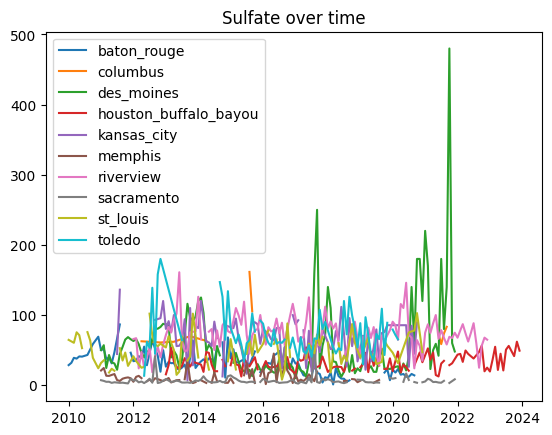

In [230]:
import matplotlib.pyplot as plt

for loc in model_df["location"].unique():
    
    subset = model_df[model_df["location"] == loc]

    plt.plot(subset["month"], subset["Sulfate"], label=loc)

plt.legend()
plt.title("Sulfate over time")
plt.show()

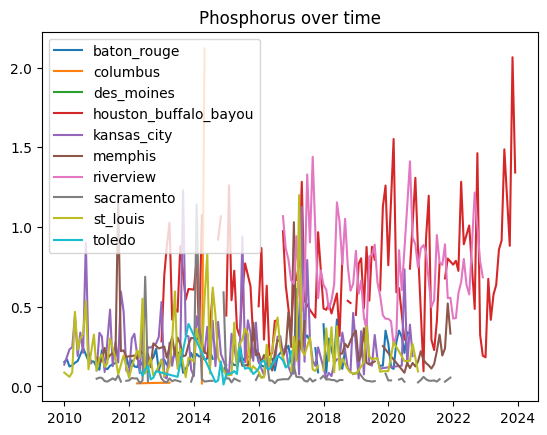

In [231]:
for loc in model_df["location"].unique():
    
    subset = model_df[model_df["location"] == loc]

    plt.plot(subset["month"], subset["Phosphorus"], label=loc)

plt.legend()
plt.title("Phosphorus over time")
plt.show()

## Begin Modeling!
We are focusing on sulfate and phosphorus because these two values proved to be the most consistent and realistically relevant across the location data.

In [185]:
model_df = model_df.sort_values(["location", "month"]).copy()
model_df["month"] = pd.to_datetime(model_df["month"])

In [ ]:
# only chose to shift by 1 due to smaller dataset, shifting by 3 removes too much data down the line
model_df["Sulfate_lag1"] = model_df.groupby("location")["Sulfate"].shift(1)
# model_df["Sulfate_lag3"] = model_df.groupby("location")["Sulfate"].shift(3)
model_df["month_of_year"] = model_df["month"].dt.month

# predict sulfate 3 months ahead
model_df["target"] = model_df.groupby("location")["Sulfate"].shift(-3)

In [196]:
model_df["Phos_lag1"] = model_df.groupby("location")["Phosphorus"].shift(1)

# predict phosphorus 3 months ahead
model_df["target"] = model_df.groupby("location")["Phosphorus"].shift(-3)

### Generating Feature Colomns
For each model data dataframe, we are adding lag data and month of year as columns.

In [ ]:
# sulfate
feature_cols = ["Sulfate_lag1", "month_of_year"]

model_data = model_df.dropna(subset=feature_cols + ["target"]).copy()

print(model_data.shape)
model_data.head()

(978, 18)


,location,month,Chloride,Phosphorus,Specific conductance,Sulfate,Total dissolved solids,pH,month_of_year,Sulfate_lag1,Phosphorus_lag1,Specific conductance_lag1,Chloride_lag1,Total dissolved solids_lag1,pH_lag1,target_sulfate,target_phosphorus,target
1,baton_rouge,2010-02-01,18.6,0.16800,324.50,31.9,186.50,8.000,2,28.6,0.15300,3797.00,1340.34,170.00,7.950,41.0,0.14775,41.0
2,baton_rouge,2010-03-01,24.8,0.12500,405.25,39.0,240.75,8.000,3,31.9,0.16800,324.50,18.60,186.50,8.000,40.7,0.15900,40.7
3,baton_rouge,2010-04-01,21.3,0.13225,387.50,37.9,221.25,7.975,4,39.0,0.12500,405.25,24.80,240.75,8.000,43.1,0.24100,43.1
4,baton_rouge,2010-05-01,18.6,0.14775,390.00,41.0,228.00,7.950,5,37.9,0.13225,387.50,21.30,221.25,7.975,58.6,0.16000,58.6
5,baton_rouge,2010-06-01,20.1,0.15900,427.00,40.7,242.00,8.000,6,41.0,0.14775,390.00,18.60,228.00,7.950,69.1,0.15550,69.1


In [ ]:
# phosphorus
feature_cols1 = ["Phos_lag1", "month_of_year"]

model_data1 = model_df.dropna(subset=feature_cols + ["target"]).copy()

print(model_data1.shape)
model_data1.head()

(781, 19)


,location,month,Chloride,Phosphorus,Specific conductance,Sulfate,Total dissolved solids,pH,month_of_year,Sulfate_lag1,Phosphorus_lag1,Specific conductance_lag1,Chloride_lag1,Total dissolved solids_lag1,pH_lag1,target_sulfate,target_phosphorus,target,Phos_lag1
1,baton_rouge,2010-02-01,18.6,0.16800,324.50,31.9,186.50,8.000,2,28.6,0.15300,3797.00,1340.34,170.00,7.950,41.0,0.14775,0.14775,0.15300
2,baton_rouge,2010-03-01,24.8,0.12500,405.25,39.0,240.75,8.000,3,31.9,0.16800,324.50,18.60,186.50,8.000,40.7,0.15900,0.15900,0.16800
3,baton_rouge,2010-04-01,21.3,0.13225,387.50,37.9,221.25,7.975,4,39.0,0.12500,405.25,24.80,240.75,8.000,43.1,0.24100,0.24100,0.12500
4,baton_rouge,2010-05-01,18.6,0.14775,390.00,41.0,228.00,7.950,5,37.9,0.13225,387.50,21.30,221.25,7.975,58.6,0.16000,0.16000,0.13225
5,baton_rouge,2010-06-01,20.1,0.15900,427.00,40.7,242.00,8.000,6,41.0,0.14775,390.00,18.60,228.00,7.950,69.1,0.15550,0.15550,0.14775


### Splitting the Data into Training and Testing Data
We are doing an 80% train and 20% test data set.

In [ ]:
from sklearn.model_selection import train_test_split

# sulfate
model_data = model_data.reset_index(drop=True)

X = model_data[feature_cols]
y = model_data["target"]
meta = model_data[["location", "month"]].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(X_train.shape, X_test.shape)

(782, 2) (196, 2)


In [ ]:
# phosphorus
model_data1 = model_data1.reset_index(drop=True)

X1 = model_data1[feature_cols1]
y1 = model_data1["target"]
meta1 = model_data1[["location", "month"]].copy()

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, test_size=0.2, shuffle=False
)

print(X_train1.shape, X_test1.shape)

(624, 2) (157, 2)


### Random Forest Regression
Fit the model and generate predictions on train and test data.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# sulfate
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
# phosphorus
model1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model1.fit(X_train1, y_train1)
pred1 = model1.predict(X_test1)

### Evaluation Metrics
Evaluate the predictions with MAE, RMSE, and R^2.

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# sulfate
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

MAE: 20.454593903279065
RMSE: 29.86845767213828
R^2: 0.03678674095086709


In [ ]:
# phosphorus
mae1 = mean_absolute_error(y_test1, pred1)
rmse1 = np.sqrt(mean_squared_error(y_test1, pred1))
r21 = r2_score(y_test1, pred1)

print("MAE1:", mae1)
print("RMSE1:", rmse1)
print("R^2_1:", r21)

MAE1: 0.16431479627481782
RMSE1: 0.23799600750430075
R^2_1: -1.3406573925050815


In [ ]:
# sulfate
results = meta.loc[X_test.index].copy()
results["actual"] = y_test.values
results["predicted"] = pred
results.head()

,location,month,actual,predicted
782,sacramento,2019-11-01,10.100,11.397105
783,sacramento,2019-12-01,7.430,16.179465
784,sacramento,2020-01-01,4.760,13.307849
785,sacramento,2020-02-01,16.655,6.433905
786,sacramento,2020-03-01,7.470,8.683344


In [ ]:
# phosphorus
results1 = meta1.loc[X_test1.index].copy()
results1["actual"] = y_test1.values
results1["predicted"] = pred1
results1.head()

,location,month,actual,predicted
624,sacramento,2020-03-01,0.029000,0.045260
625,sacramento,2020-05-01,0.032000,0.055825
626,sacramento,2020-06-01,0.035000,0.470256
627,sacramento,2020-07-01,0.031667,0.113160
628,sacramento,2020-08-01,0.028333,0.060302


### Defining Risk Thresholds and Scores
Based on real-world regulations, the *sulfate threshold* is approximately 250 mg/l, and the *phosphorus threshold* is approximately 0.1 mg/l.

In [192]:
sulfate_threshold = 250

results["risk_score"] = results["predicted"] / sulfate_threshold

def risk_level(score):
    if score >= 1.0:
        return "High"
    elif score >= 0.8:
        return "Medium"
    else:
        return "Low"

results["risk_level"] = results["risk_score"].apply(risk_level)

results.head()

,location,month,actual,predicted,risk_score,risk_level
782,sacramento,2019-11-01,10.100,11.397105,0.045588,Low
783,sacramento,2019-12-01,7.430,16.179465,0.064718,Low
784,sacramento,2020-01-01,4.760,13.307849,0.053231,Low
785,sacramento,2020-02-01,16.655,6.433905,0.025736,Low
786,sacramento,2020-03-01,7.470,8.683344,0.034733,Low


In [203]:
phos_threshold = 0.1

results1["risk_score"] = results1["predicted"] / phos_threshold

def risk_level(score):
    if score >= 1.0:
        return "High"
    elif score >= 0.8:
        return "Medium"
    else:
        return "Low"

results1["risk_level"] = results1["risk_score"].apply(risk_level)

results1.head()

,location,month,actual,predicted,risk_score,risk_level
624,sacramento,2020-03-01,0.029000,0.045260,0.452596,Low
625,sacramento,2020-05-01,0.032000,0.055825,0.558248,Low
626,sacramento,2020-06-01,0.035000,0.470256,4.702562,High
627,sacramento,2020-07-01,0.031667,0.113160,1.131603,High
628,sacramento,2020-08-01,0.028333,0.060302,0.603024,Low


In [ ]:
# sulfate
risk_summary = (
    results.groupby("location")["risk_score"]
    .max()
    .reset_index()
    .sort_values("risk_score", ascending=False)
)

risk_summary

,location,risk_score
1,st_louis,0.725975
2,toledo,0.491210
0,sacramento,0.172707


In [ ]:
# phosphorus
risk_summary1 = (
    results1.groupby("location")["risk_score"]
    .max()
    .reset_index()
    .sort_values("risk_score", ascending=False)
)

risk_summary1

,location,risk_score
1,st_louis,9.311803
2,toledo,7.633536
0,sacramento,4.702562


### Plot and Visualize the Predictions

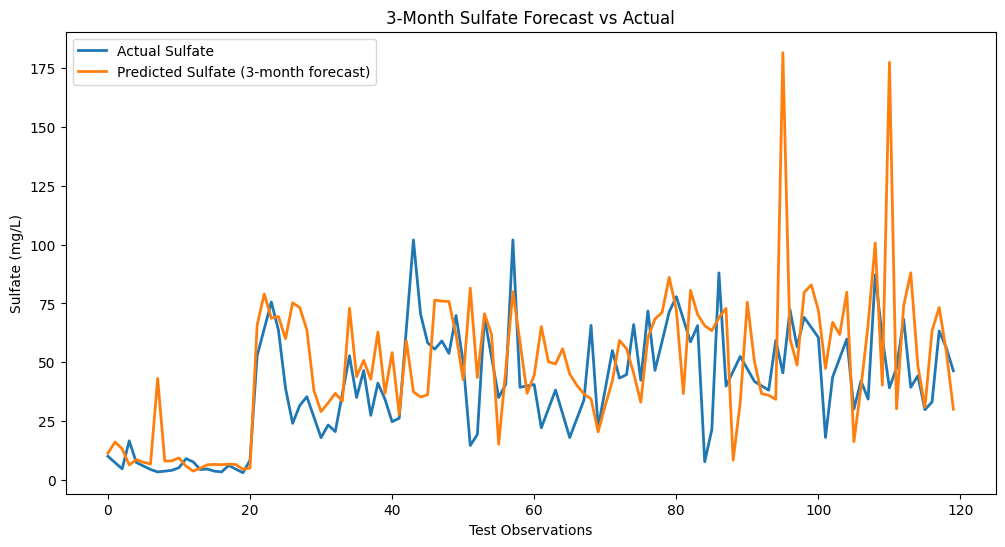

In [194]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    results["actual"].values[:120],
    label="Actual Sulfate",
    linewidth=2
)

plt.plot(
    results["predicted"].values[:120],
    label="Predicted Sulfate (3-month forecast)",
    linewidth=2
)

plt.title("3-Month Sulfate Forecast vs Actual")
plt.xlabel("Test Observations")
plt.ylabel("Sulfate (mg/L)")
plt.legend()
plt.show()

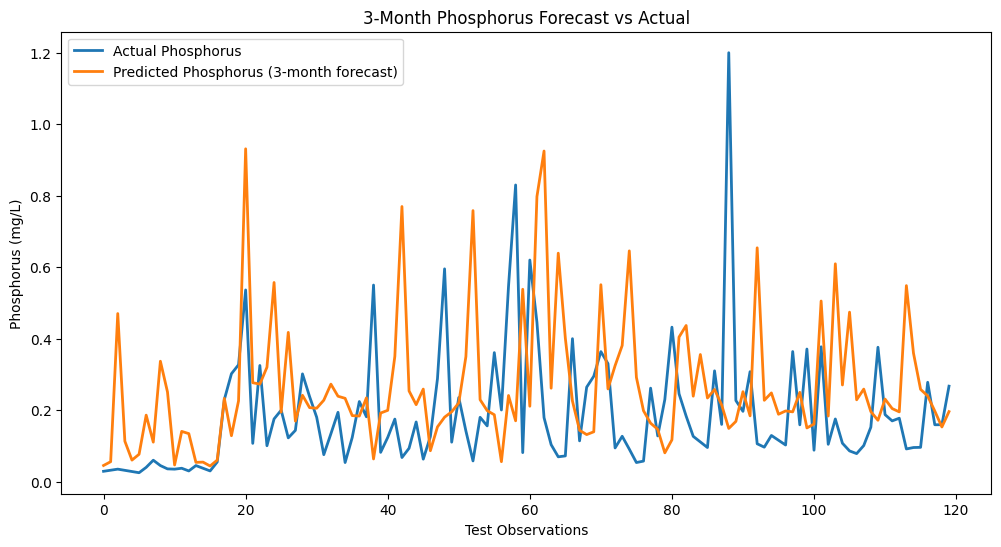

In [205]:
plt.figure(figsize=(12,6))

plt.plot(
    results1["actual"].values[:120],
    label="Actual Phosphorus",
    linewidth=2
)

plt.plot(
    results1["predicted"].values[:120],
    label="Predicted Phosphorus (3-month forecast)",
    linewidth=2
)

plt.title("3-Month Phosphorus Forecast vs Actual")
plt.xlabel("Test Observations")
plt.ylabel("Phosphorus (mg/L)")
plt.legend()
plt.show()

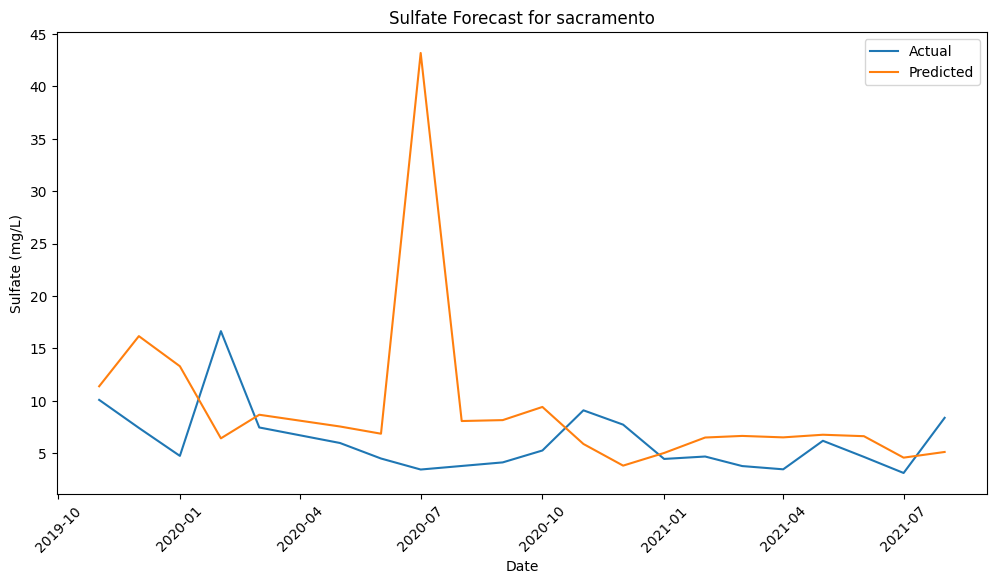

In [195]:
loc = "sacramento"

subset = results[results["location"] == loc]

plt.figure(figsize=(12,6))

plt.plot(subset["month"], subset["actual"], label="Actual")
plt.plot(subset["month"], subset["predicted"], label="Predicted")

plt.title(f"Sulfate Forecast for {loc}")
plt.ylabel("Sulfate (mg/L)")
plt.xlabel("Date")
plt.legend()

plt.xticks(rotation=45)
plt.show()

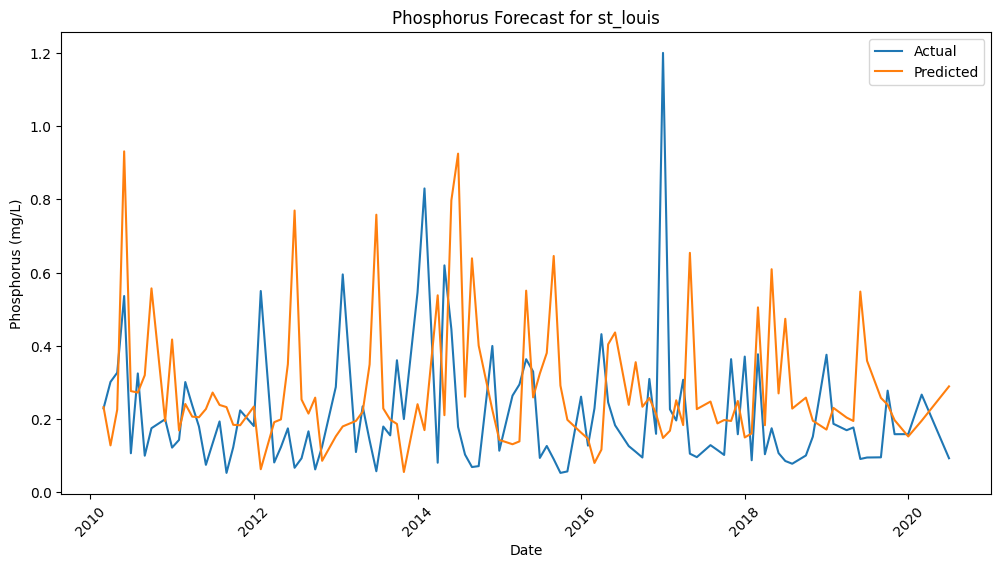

In [207]:
loc1 = "st_louis"

subset1 = results1[results1["location"] == loc1]

plt.figure(figsize=(12,6))

plt.plot(subset1["month"], subset1["actual"], label="Actual")
plt.plot(subset1["month"], subset1["predicted"], label="Predicted")

plt.title(f"Phosphorus Forecast for {loc1}")
plt.ylabel("Phosphorus (mg/L)")
plt.xlabel("Date")
plt.legend()

plt.xticks(rotation=45)
plt.show()

In [208]:
results

,location,month,actual,predicted,risk_score,risk_level
782,sacramento,2019-11-01,10.100,11.397105,0.045588,Low
783,sacramento,2019-12-01,7.430,16.179465,0.064718,Low
784,sacramento,2020-01-01,4.760,13.307849,0.053231,Low
785,sacramento,2020-02-01,16.655,6.433905,0.025736,Low
786,sacramento,2020-03-01,7.470,8.683344,0.034733,Low
...,...,...,...,...,...,...
973,toledo,2019-10-01,79.300,82.151857,0.328607,Low
974,toledo,2019-11-01,71.600,46.391951,0.185568,Low
975,toledo,2019-12-01,65.300,75.290562,0.301162,Low
976,toledo,2020-01-01,65.300,70.223268,0.280893,Low


In [209]:
results1

,location,month,actual,predicted,risk_score,risk_level
624,sacramento,2020-03-01,0.029000,0.045260,0.452596,Low
625,sacramento,2020-05-01,0.032000,0.055825,0.558248,Low
626,sacramento,2020-06-01,0.035000,0.470256,4.702562,High
627,sacramento,2020-07-01,0.031667,0.113160,1.131603,High
628,sacramento,2020-08-01,0.028333,0.060302,0.603024,Low
...,...,...,...,...,...,...
776,toledo,2016-09-01,0.132333,0.234432,2.344322,High
777,toledo,2016-10-01,0.219000,0.249110,2.491102,High
778,toledo,2016-11-01,0.214744,0.198637,1.986370,High
779,toledo,2016-12-01,0.210488,0.203047,2.030472,High


## Store the Results Output
Locally stored (for now!). Plan to integrate S3 in the future.

In [212]:
import os
os.makedirs("data/final", exist_ok=True)

results.to_csv("data/final/sulfate_predictions.csv", index=False)
risk_summary.to_csv("data/final/sulfate_location_risk_summary.csv", index=False)

results1.to_csv("data/final/phosphorus_predictions.csv", index=False)
risk_summary1.to_csv("data/final/phosphorus_location_risk_summary.csv", index=False)